Setup (imports, style, helpers)

In [1]:
# Setup: imports, plotting style, and helpers 
import os
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../data"
PLOTS_DIR = "../plots"

# Subtle, readable matplotlib defaults
plt.rcParams.update({
    "figure.figsize": (9, 5.6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.color": "#e9ecef",
    "grid.linestyle": "-",
    "grid.linewidth": 0.6,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "DejaVu Sans"
})

# A soft, muted palette we can reuse
PALETTE = ["#7da0a6", "#a6a67d", "#a67d98", "#7da67f", "#a6907d", "#7f86a6"]

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def load_bias(path):
    df = pd.read_csv(path)
    # If ranks are JSON strings (e.g. {"en":1,...}), keep them for later if needed
    # but main plots use normalized per-language metrics when present.
    return df

def zscore_by_language(df, metric_col="pagerank_norm_perlang"):
    """Return a copy with z-scored metric within each language for better comparability."""
    df = df.copy()
    def _z(g):
        x = g[metric_col].astype(float)
        mu, sd = x.mean(), x.std(ddof=0)
        if sd == 0 or np.isnan(sd):
            return pd.Series(np.zeros(len(x)), index=g.index)
        return (x - mu) / sd
    df[f"{metric_col}_z"] = df.groupby("language", dropna=False, sort=False).apply(_z).reset_index(level=0, drop=True)
    return df

def coverage_by_property(df, prop_col, top_n=15):
    cov = (
        df.dropna(subset=[prop_col])
          .assign(language=df["language"].fillna("unknown"))
          .groupby([prop_col, "language"], as_index=False)["qid"]
          .nunique()
    )
    # Pivot to see languages side-by-side
    cov_pivot = cov.pivot(index=prop_col, columns="language", values="qid").fillna(0).astype(int)
    # Sort by total coverage across languages
    cov_pivot["__total__"] = cov_pivot.sum(axis=1)
    cov_pivot = cov_pivot.sort_values("__total__", ascending=False).head(top_n).drop(columns="__total__")
    return cov_pivot

def plot_stacked_coverage(cov_pivot, title, outpath):
    ensure_dir(os.path.dirname(outpath))
    cov_pivot.plot(kind="bar", stacked=True, linewidth=0, color=PALETTE[:len(cov_pivot.columns)])
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Number of QIDs")
    plt.tight_layout()
    plt.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()

def violin_with_box(df, prop_col, metric_col, outpath, max_labels=10):
    """Violin + box (overlaid) per language for top labels of a property by count."""
    ensure_dir(os.path.dirname(outpath))
    # Choose top labels in this property
    top_labels = (
        df.dropna(subset=[prop_col])
          .groupby(prop_col)["qid"].nunique()
          .sort_values(ascending=False)
          .head(max_labels)
          .index.tolist()
    )
    sub = df[df[prop_col].isin(top_labels)].copy()
    if sub.empty:
        print(f" Nothing to plot for {prop_col} (violin).")
        return

    # One figure per label: language on x-axis, distribution on y
    n = len(top_labels)
    cols = 2
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(10, 4*rows))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()

    for ax, label in zip(axes, top_labels):
        part = sub[sub[prop_col] == label]
        langs = sorted(part["language"].dropna().unique().tolist())
        data = [part[part["language"] == lg][metric_col].astype(float).values for lg in langs]

        # violin
        vparts = ax.violinplot(data, showmeans=False, showmedians=False, showextrema=False)
        for vp in vparts['bodies']:
            vp.set_alpha(0.35)
            vp.set_facecolor("#7da0a6")

        # box overlay
        ax.boxplot(data, widths=0.15, showfliers=False)

        ax.set_title(str(label))
        ax.set_xticks(range(1, len(langs)+1))
        ax.set_xticklabels(langs, rotation=0)
        ax.set_ylabel(metric_col)

    # Remove any unused axes
    for j in range(len(top_labels), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"{metric_col} distributions across languages per {prop_col}", y=0.99)
    plt.tight_layout()
    plt.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()

def corr_heatmap(df, metric_cols, outpath, title="Metric correlations"):
    ensure_dir(os.path.dirname(outpath))
    # Compute correlations within the filtered df
    X = df[metric_cols].astype(float)
    C = np.corrcoef(X.T)
    fig, ax = plt.subplots(figsize=(6.5, 5.8))
    im = ax.imshow(C, cmap="Greys", vmin=-1, vmax=1)
    ax.set_xticks(range(len(metric_cols)))
    ax.set_yticks(range(len(metric_cols)))
    ax.set_xticklabels(metric_cols, rotation=45, ha="right")
    ax.set_yticklabels(metric_cols)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Pearson r")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()

def scatter_pairs(df, metric_cols, outdir, title_prefix):
    """Save a small multiple of scatterplots for each metric pair, faceted by language."""
    ensure_dir(outdir)
    langs = sorted(df["language"].dropna().unique().tolist())
    for i in range(len(metric_cols)):
        for j in range(i+1, len(metric_cols)):
            xcol, ycol = metric_cols[i], metric_cols[j]
            # One figure per pair
            plt.figure(figsize=(8.2, 6))
            for idx, lg in enumerate(langs):
                sub = df[df["language"] == lg]
                plt.scatter(sub[xcol], sub[ycol], s=11, alpha=0.6, label=lg)
            plt.xlabel(xcol)
            plt.ylabel(ycol)
            plt.title(f"{title_prefix}: {xcol} vs {ycol}")
            plt.legend(frameon=True)
            plt.tight_layout()
            fname = f"{xcol}_vs_{ycol}.png".replace("/", "_")
            plt.savefig(os.path.join(outdir, fname), dpi=200, bbox_inches="tight")
            plt.show()

def add_zscores(df, metric_cols):
    """Add z-scored versions (by language) for each metric in metric_cols."""
    out = df.copy()
    for m in metric_cols:
        out = zscore_by_language(out, metric_col=m)
    return out


Occupation visualisations

In [11]:
import os
import re
import pandas as pd

DATA_DIR = "../data"
PLOTS_DIR = "../plots"

def extract_qid(val):
    if pd.isna(val):
        return None
    match = re.search(r"(Q\d+)", str(val))
    return match.group(1) if match else None

# Load metrics
perlang_df = pd.read_csv(os.path.join(DATA_DIR, "bias_metrics_perlang.csv"))
perlang_df["qid"] = perlang_df["qid"].apply(extract_qid)

# Load occupation mapping
occ_map = pd.read_csv(os.path.join(DATA_DIR, "occupation_mapped.csv"))
if "qid" not in occ_map.columns:
    occ_map["qid"] = occ_map["item"].apply(extract_qid)

# Keep only necessary columns
occ_map = occ_map[["qid", "occupation_category"]].dropna(subset=["qid"]).drop_duplicates()

# Merge
df_occ = perlang_df.merge(occ_map, on="qid", how="inner")
print(f"Occupation merged: {df_occ.shape}, languages: {df_occ['language'].nunique()}")
df_occ.head()


Occupation merged: (768, 9), languages: 4


,qid,language,pagerank_norm_perlang,in_degree_norm_perlang,out_degree_norm_perlang,betweenness_norm_perlang,eigenvector_norm_perlang,clustering_norm_perlang,occupation_category
0,Q16211894,en,0.012091,0.014800,0.142442,0.023028,0.000612,0.042546,Sports
1,Q8001787,en,0.000681,0.000638,0.014120,0.001938,0.000040,0.000000,Sports
2,Q63847124,en,0.000241,0.000273,0.012874,0.000571,0.000004,0.000000,Science
3,Q63847124,en,0.000241,0.000273,0.012874,0.000571,0.000004,0.000000,"Arts, Literature & Humanities"
4,Q720474,en,0.000206,0.000273,0.006229,0.001902,0.000007,0.000000,Economics & Politics


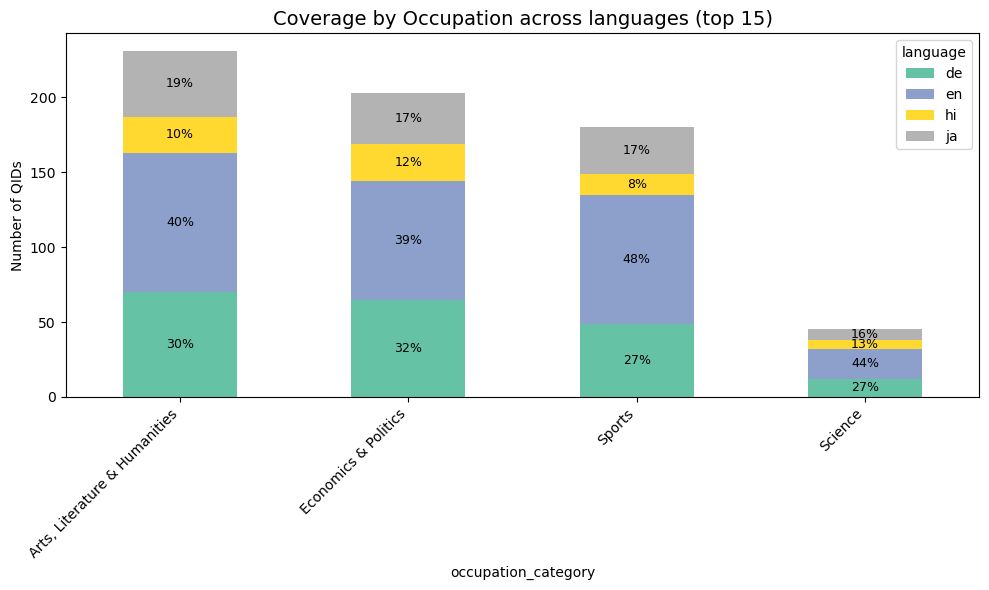

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os

def coverage_counts(df, prop_col, top_n=15):
    # counts per (property, language)
    cov = (
        df.dropna(subset=[prop_col])
          .groupby([prop_col, "language"], as_index=False)["qid"]
          .nunique()
    )
    cov_pivot = cov.pivot(index=prop_col, columns="language", values="qid").fillna(0).astype(int)
    # choose top-N by total coverage
    top_idx = cov_pivot.sum(axis=1).sort_values(ascending=False).head(top_n).index
    return cov_pivot.loc[top_idx]

# --- use your merged occupation df ---
cov_occ_counts = coverage_counts(df_occ, "occupation_category", top_n=15)

# percentages only for TEXT labels (derived from counts)
cov_occ_pct = cov_occ_counts.div(cov_occ_counts.sum(axis=1), axis=0) * 100

ax = cov_occ_counts.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="Set2")
plt.title("Coverage by Occupation across languages (top 15)", fontsize=14)
plt.ylabel("Number of QIDs")
plt.xticks(rotation=45, ha="right")

# add % labels inside each stacked segment
for i, (idx, counts_row) in enumerate(cov_occ_counts.iterrows()):
    cum = 0
    total = counts_row.sum()
    for lang, count in counts_row.items():
        if count <= 0:
            continue
        pct = 100 * count / total
        # center of the current segment
        y_center = cum + count / 2.0
        # only annotate if the segment is big enough to read
        if pct >= 5:
            ax.text(i, y_center, f"{pct:.0f}%", ha="center", va="center", fontsize=9)
        cum += count

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "occupation_coverage_counts_with_pct.png"), dpi=200, bbox_inches="tight")
plt.show()


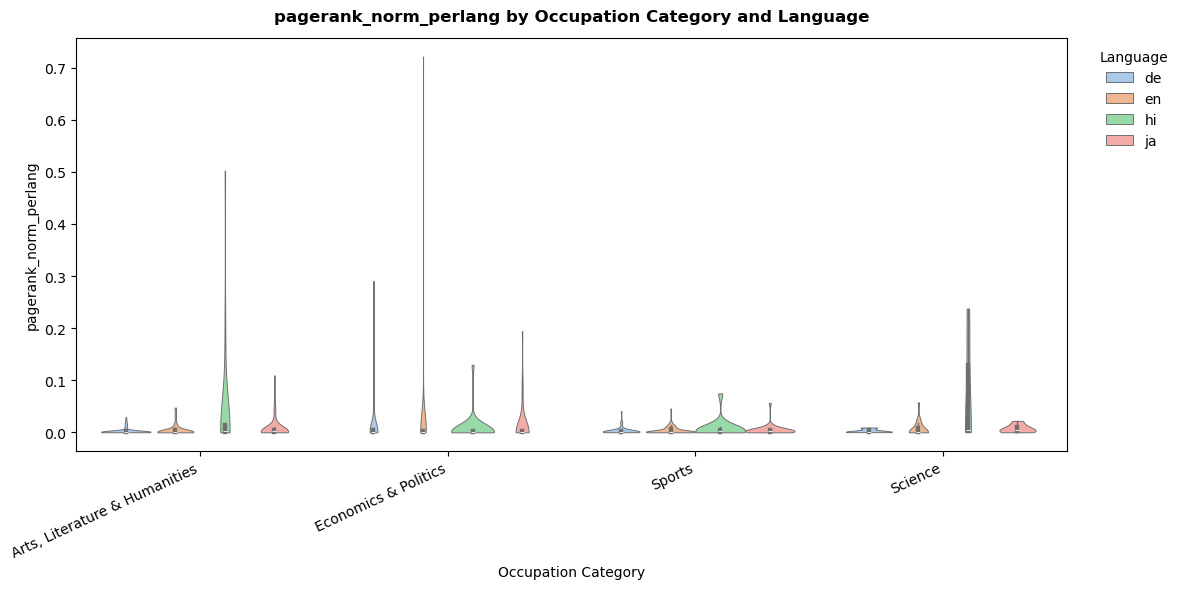

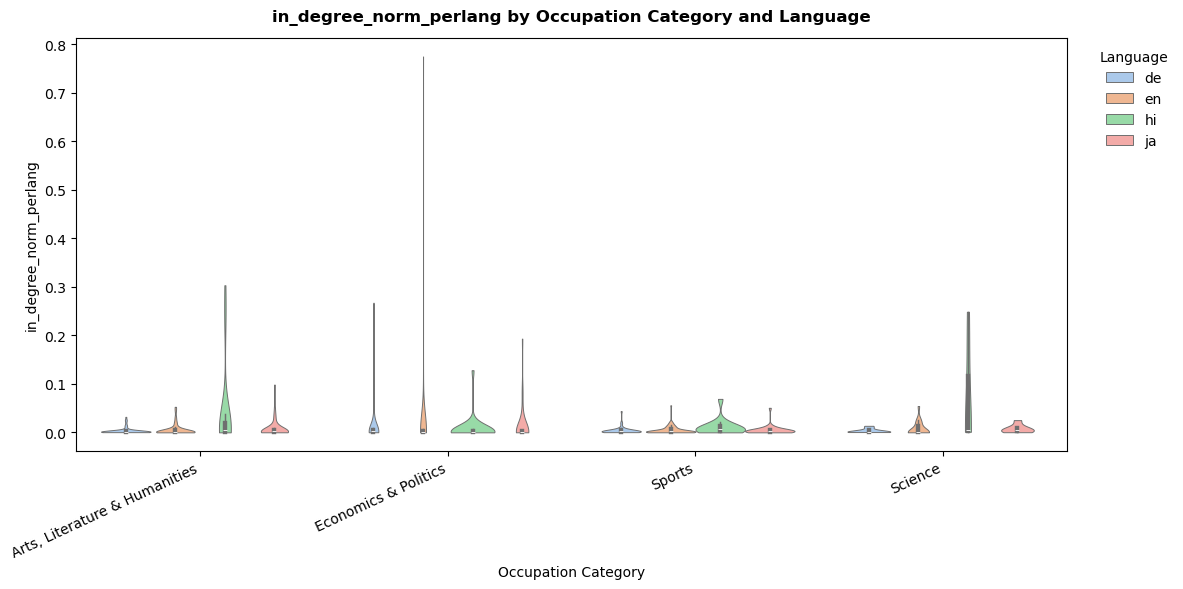

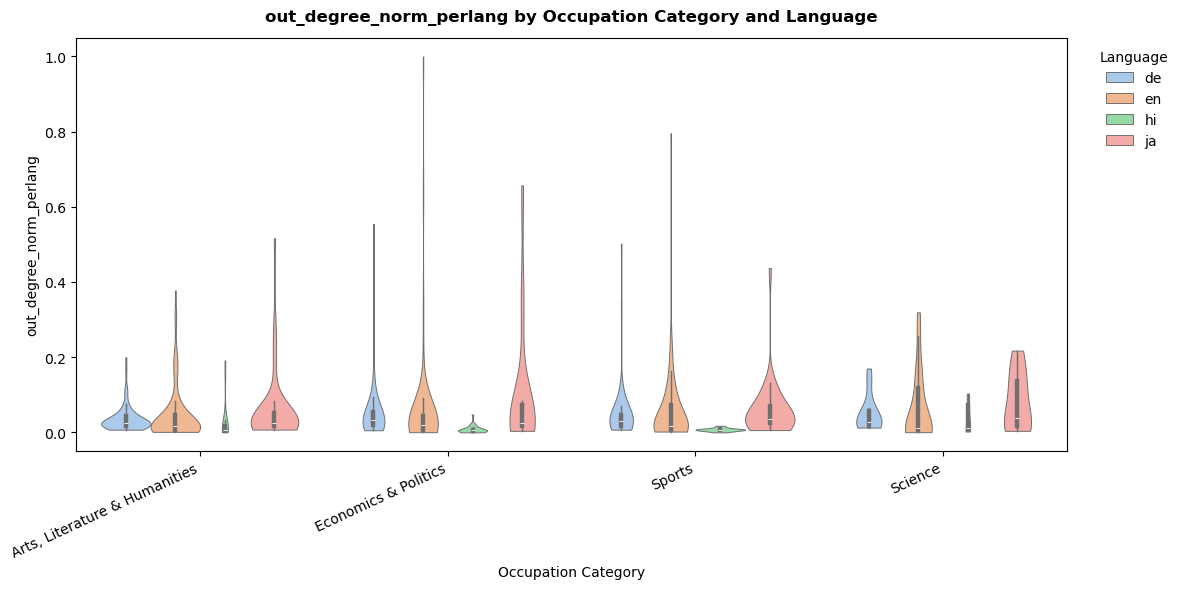

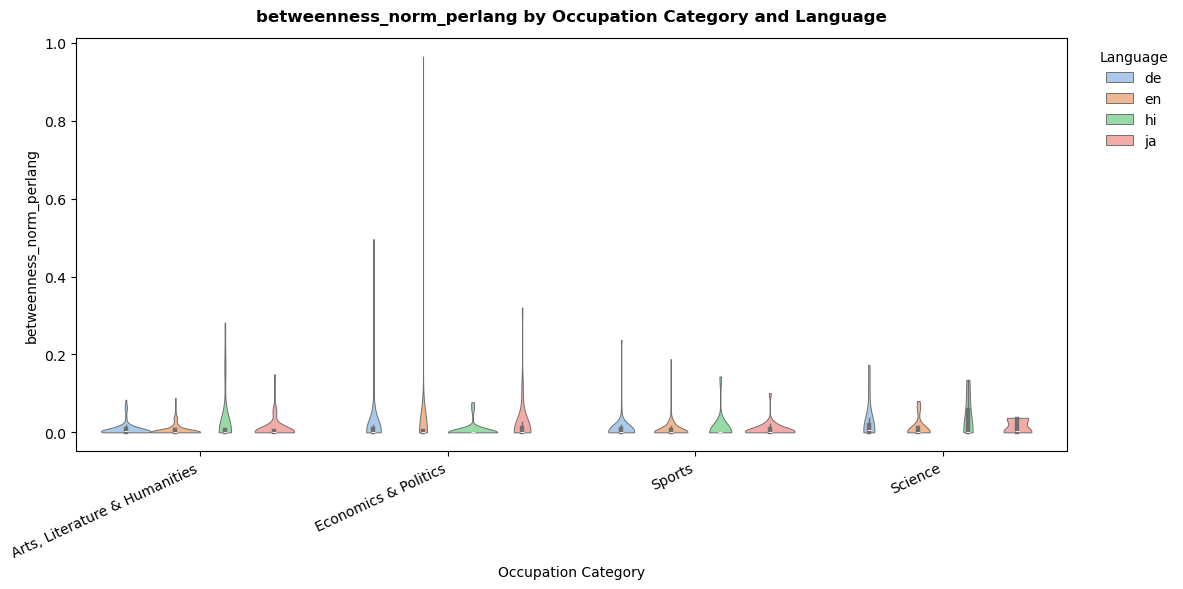

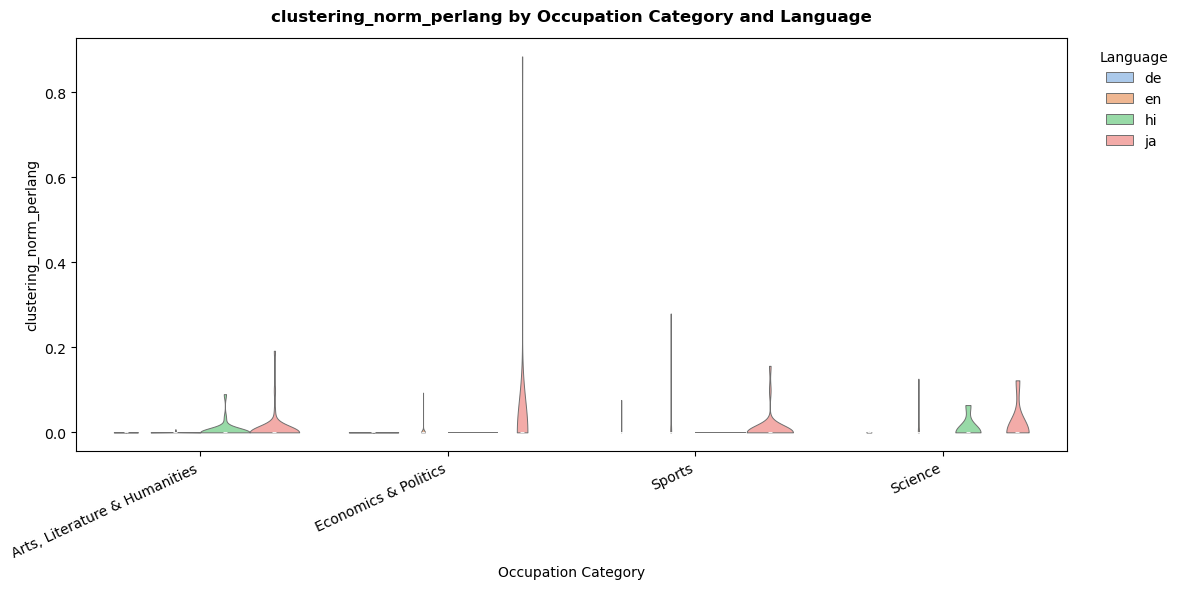

In [9]:
# --- GROUPED VIOLINS: per occupation_category, split by language ---

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# pick the metrics you actually have
metrics = [c for c in [
    "pagerank_norm_perlang","in_degree_norm_perlang","out_degree_norm_perlang",
    "betweenness_norm_perlang","clustering_norm_perlang"
] if c in df_occ.columns]

# (optional) keep top-N occupation categories by sample size to keep plots readable
TOP_N = 10
top_occ = (
    df_occ.groupby("occupation_category")["qid"]
          .nunique().sort_values(ascending=False).head(TOP_N).index
)
df_plot = df_occ[df_occ["occupation_category"].isin(top_occ)].copy()

# make language order stable
lang_order = sorted(df_plot["language"].dropna().unique())

for m in metrics:
    plt.figure(figsize=(12, 6))
    ax = sns.violinplot(
        data=df_plot,
        x="occupation_category",
        y=m,
        hue="language",
        order=top_occ,
        hue_order=lang_order,
        cut=0,
        inner="box",
        linewidth=0.7,
        palette="pastel"   # subtle colors
    )
    ax.set_title(f"{m} by Occupation Category and Language", pad=12, weight="bold")
    ax.set_xlabel("Occupation Category")
    ax.set_ylabel(m)
    ax.legend(title="Language", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()


/opt/anaconda3/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

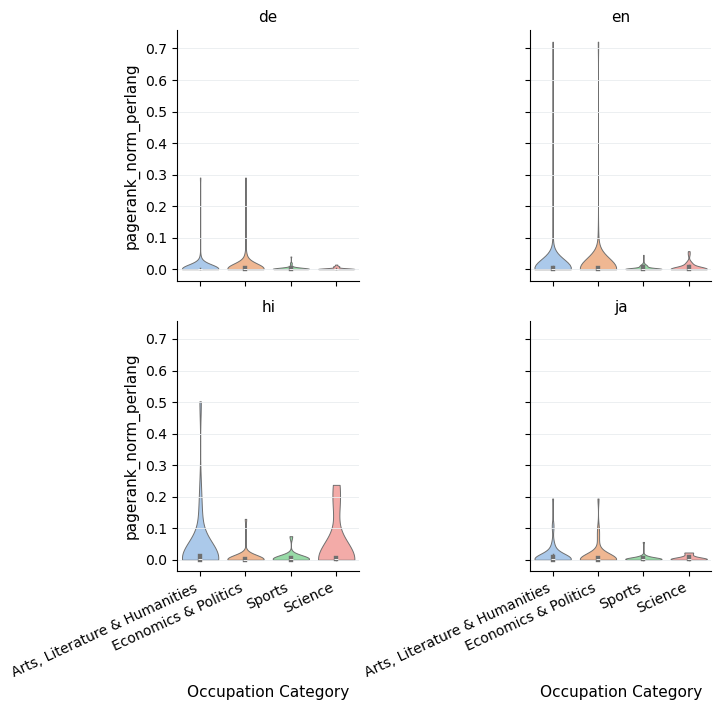

In [16]:
# --- FACETED VIOLINS: one panel per language ---

import seaborn as sns
import matplotlib.pyplot as plt

metric = "pagerank_norm_perlang"  # <- change if you want another metric
assert metric in df_occ.columns, f"{metric} not found."

TOP_N = 10
top_occ = (
    df_occ.groupby("occupation_category")["qid"]
          .nunique().sort_values(ascending=False).head(TOP_N).index
)
df_plot = df_occ[df_occ["occupation_category"].isin(top_occ)].copy()

g = sns.FacetGrid(
    df_plot, col="language", col_wrap=2, sharey=True, height=3.6,
    col_order=sorted(df_plot["language"].unique())
)
g.map_dataframe(
    sns.violinplot,
    x="occupation_category", y=metric, order=top_occ,
    cut=0, inner="box", linewidth=0.7, palette="pastel"
)
g.set_titles(col_template="{col_name}")
for ax in g.axes.ravel():
    ax.set_xlabel("Occupation Category")
    ax.set_ylabel(metric)
    for label in ax.get_xticklabels():
        label.set_rotation(25)
        label.set_horizontalalignment("right")
plt.tight_layout()
plt.show()


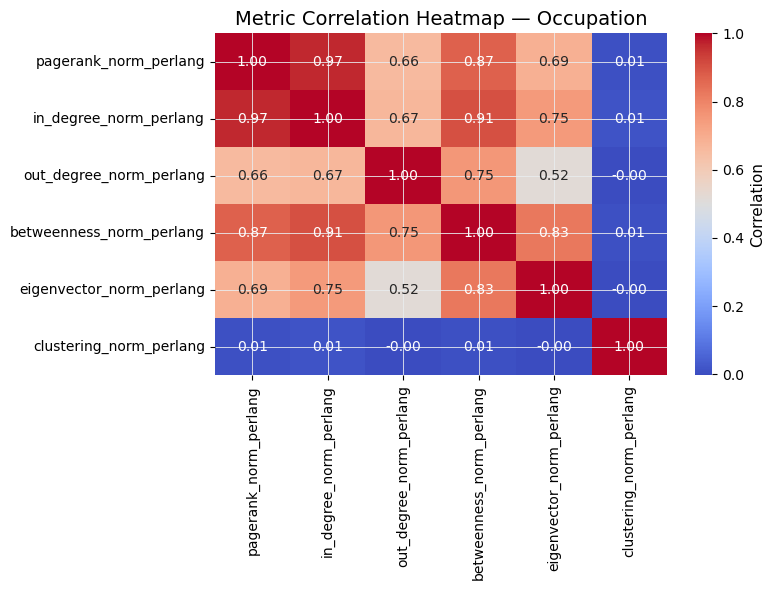

In [14]:
from scipy.stats import zscore

metric_cols = [c for c in df_occ.columns if c.endswith("_norm_perlang")]
df_corr = df_occ.groupby("qid")[metric_cols].mean().apply(zscore)

plt.figure(figsize=(8,6))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Correlation'})
plt.title("Metric Correlation Heatmap — Occupation", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "occupation_corr_heatmap.png"))
plt.show()


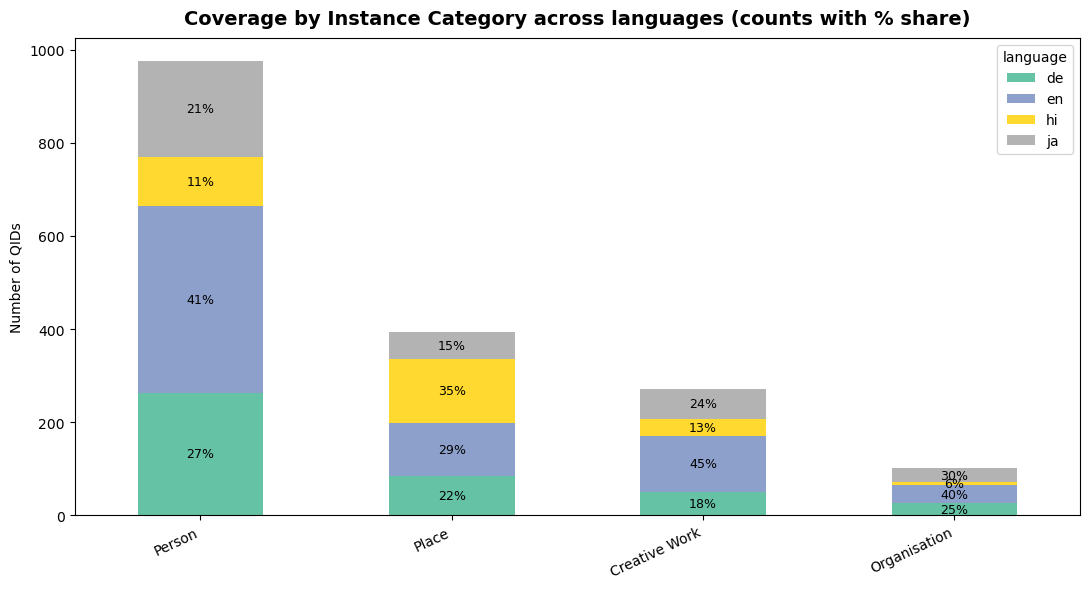

In [15]:
import os, re
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../data"
PLOTS_DIR = "../plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# ---------- helpers ----------
def extract_qid(val):
    if pd.isna(val): return None
    m = re.search(r"(Q\d+)", str(val))
    return m.group(1) if m else None

def load_perlang():
    perlang = pd.read_csv(os.path.join(DATA_DIR, "bias_metrics_perlang.csv"))
    # ensure qid is clean like 'Q123'
    perlang["qid"] = perlang["qid"].apply(extract_qid)
    return perlang

def load_instance_mapping():
    inst = pd.read_csv(os.path.join(DATA_DIR, "bias_metrics_instance.csv"))
    # unify column names
    if "qid" not in inst.columns and "item" in inst.columns:
        inst = inst.rename(columns={"item":"qid"})
    inst["qid"] = inst["qid"].apply(extract_qid)
    # prefer a tidy category column
    prop_col = "instance_category" if "instance_category" in inst.columns else "instanceOfLabel"
    return inst[["qid", prop_col]].dropna(), prop_col

def coverage_by_property_counts(df, prop_col, top_n=12):
    cov = (df.dropna(subset=[prop_col])
             .groupby([prop_col, "language"], as_index=False)["qid"]
             .nunique())
    pivot = cov.pivot(index=prop_col, columns="language", values="qid").fillna(0).astype(int)
    # keep top categories by total size
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).head(top_n).index]
    return pivot

def plot_counts_with_percent_labels(pivot, title, outpng):
    ax = pivot.plot(kind="bar", stacked=True, figsize=(11,6), colormap="Set2")
    ax.set_title(title, fontsize=14, weight="bold", pad=10)
    ax.set_ylabel("Number of QIDs")
    ax.set_xlabel("")
    plt.xticks(rotation=25, ha="right")

    # annotate % inside each stack segment
    langs = list(pivot.columns)
    for i, cat in enumerate(pivot.index):
        total = pivot.loc[cat].sum()
        bottom = 0
        for lang in langs:
            count = pivot.loc[cat, lang]
            if count > 0 and total > 0:
                pct = 100.0 * count / total
                ax.text(i, bottom + count/2.0, f"{pct:.0f}%",
                        ha="center", va="center", fontsize=9)
            bottom += count

    plt.tight_layout()
    plt.savefig(outpng, dpi=200, bbox_inches="tight")
    plt.show()

# ---------- run (INSTANCE version with percent labels) ----------
perlang = load_perlang()
inst_map, inst_col = load_instance_mapping()

# merge per-language metrics with instance categories
df_instance = perlang.merge(inst_map, on="qid", how="inner")

# build counts table and plot
cov_inst = coverage_by_property_counts(df_instance, inst_col, top_n=12)
plot_counts_with_percent_labels(
    cov_inst,
    "Coverage by Instance Category across languages (counts with % share)",
    os.path.join(PLOTS_DIR, "instance_coverage_counts_with_pct.png")
)


In [13]:
perlang = load_perlang()

inst_map = pd.read_csv(os.path.join(DATA_DIR, "instance_mapped.csv"))
if "qid" not in inst_map.columns:
    inst_map["qid"] = inst_map["item"].apply(extract_qid)

inst_map = inst_map[["qid", "instance_category"]].dropna().drop_duplicates()

df_instance = perlang.merge(inst_map, on="qid", how="inner")
print(f"Instance merged: {df_instance.shape}, languages: {df_instance['language'].nunique()}")
df_instance.head(3)


Instance merged: (1830, 9), languages: 4


,qid,language,pagerank_norm_perlang,in_degree_norm_perlang,out_degree_norm_perlang,betweenness_norm_perlang,eigenvector_norm_perlang,clustering_norm_perlang,instance_category
0,Q157032,en,0.031115,0.032652,0.117110,0.026394,3.277849e-03,0.0,Place
1,Q4699838,en,0.001824,0.002550,0.006229,0.000000,2.424159e-88,0.0,Place
2,Q17770988,en,0.001797,0.001776,0.031146,0.002798,2.651319e-05,0.0,Organisation


In [22]:
perlang = load_perlang()

cit = pd.read_csv(os.path.join(DATA_DIR, "citizenship.csv"))
if "qid" not in cit.columns:
    cit["qid"] = cit["item"].apply(extract_qid)

cit = cit[["qid", "citizenshipLabel"]].dropna().drop_duplicates()
df_citz = perlang.merge(cit, on="qid", how="inner")
print(f"Citizenship merged: {df_citz.shape}, languages: {df_citz['language'].nunique()}")
df_citz.head(3)


Citizenship merged: (912, 9), languages: 4


,qid,language,pagerank_norm_perlang,in_degree_norm_perlang,out_degree_norm_perlang,betweenness_norm_perlang,eigenvector_norm_perlang,clustering_norm_perlang,citizenshipLabel
0,Q16211894,en,0.012091,0.014800,0.142442,0.023028,0.000612,0.042546,New Zealand
1,Q63847124,en,0.000241,0.000273,0.012874,0.000571,0.000004,0.000000,Russia
2,Q63847124,en,0.000241,0.000273,0.012874,0.000571,0.000004,0.000000,Israel


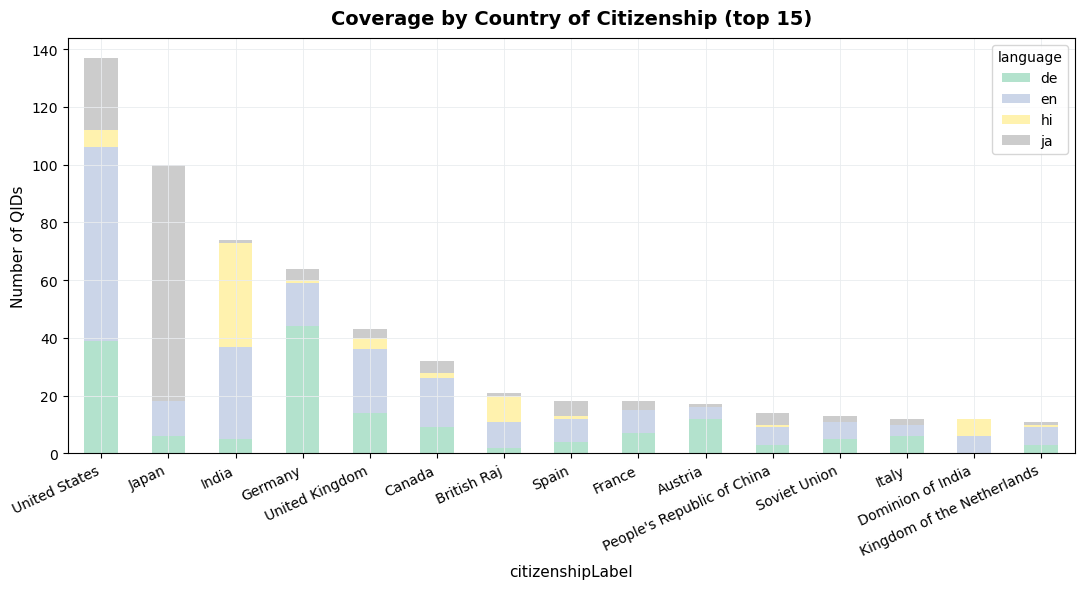

In [23]:
cov_citz = coverage_by_property(df_citz, "citizenshipLabel", top_n=15)
stacked_coverage_plot(cov_citz,
    "Coverage by Country of Citizenship (top 15)",
    os.path.join(PLOTS_DIR, "citizenship_coverage.png"))


In [25]:
perlang = load_perlang()

org = pd.read_csv(os.path.join(DATA_DIR, "origin.csv"))
if "qid" not in org.columns:
    org["qid"] = org["item"].apply(extract_qid)

org = org[["qid", "originLabel"]].dropna().drop_duplicates()
df_origin = perlang.merge(org, on="qid", how="inner")
print(f"Origin merged: {df_origin.shape}, languages: {df_origin['language'].nunique()}")
df_origin.head(3)


Origin merged: (277, 9), languages: 4


,qid,language,pagerank_norm_perlang,in_degree_norm_perlang,out_degree_norm_perlang,betweenness_norm_perlang,eigenvector_norm_perlang,clustering_norm_perlang,originLabel
0,Q5955106,en,0.001098,0.001138,0.003322,0.000242,2.456654e-07,0.0,Iran
1,Q14391653,en,0.008612,0.008971,0.100498,0.023990,3.559944e-05,0.0,Canada
2,Q764483,en,0.005781,0.007377,0.041528,0.003339,3.974110e-08,0.0,United States


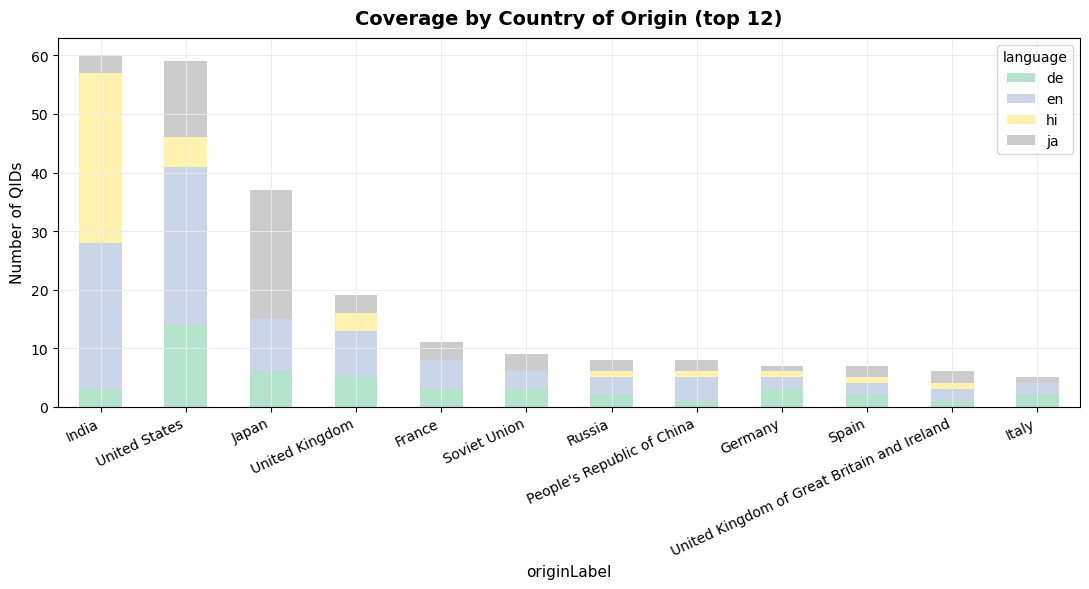

In [26]:
cov_org = coverage_by_property(df_origin, "originLabel", top_n=12)
stacked_coverage_plot(cov_org,
    "Coverage by Country of Origin (top 12)",
    os.path.join(PLOTS_DIR, "origin_coverage.png"))


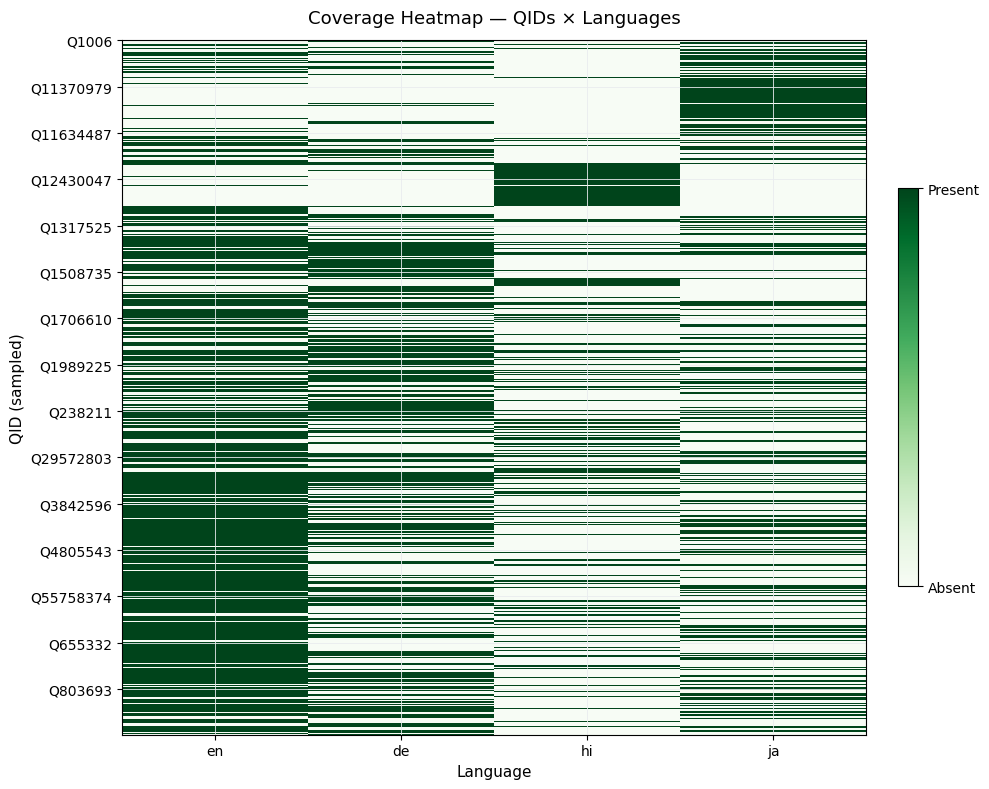

Coverage % per language:
language
en    65.0
de    45.3
ja    36.8
hi    26.6


In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Optionally sample rows for readability (e.g., max 600)
MAX_ROWS = 600
plot_mat = presence
if len(plot_mat) > MAX_ROWS:
    plot_mat = plot_mat.sample(MAX_ROWS, random_state=42).sort_index()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(plot_mat.values, aspect="auto", interpolation="nearest", cmap="Greens", vmin=0, vmax=1)

# tidy axes
ax.set_xticks(np.arange(plot_mat.shape[1]))
ax.set_xticklabels(plot_mat.columns, rotation=0)
# show fewer y ticks (QIDs can be long)
step = max(1, plot_mat.shape[0] // 15)
yticks = np.arange(0, plot_mat.shape[0], step)
ax.set_yticks(yticks)
ax.set_yticklabels(plot_mat.index[yticks])

ax.set_title("Coverage Heatmap — QIDs × Languages", pad=12)
ax.set_xlabel("Language")
ax.set_ylabel("QID (sampled)" if len(plot_mat)!=len(presence) else "QID")

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.04)
cbar.set_ticks([0,1])
cbar.set_ticklabels(["Absent","Present"])

outpath = os.path.join(PLOTS_DIR, "coverage_heatmap_languages.png")
plt.tight_layout()
plt.savefig(outpath, dpi=200)
plt.show()

# quick coverage stats
coverage_pct = (presence.mean(axis=0) * 100).sort_values(ascending=False).round(1)
print("Coverage % per language:")
print(coverage_pct.to_string())


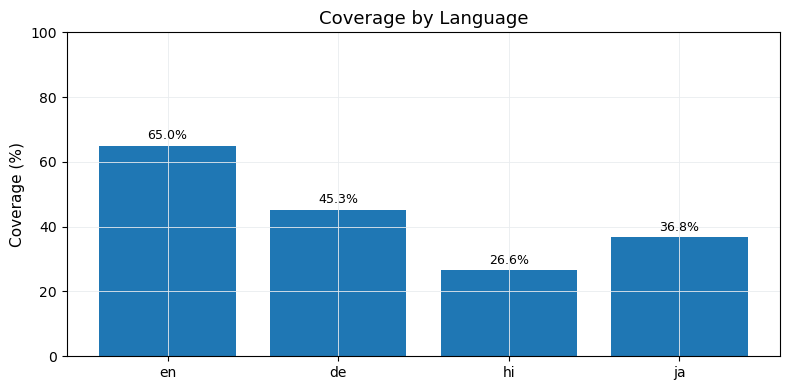

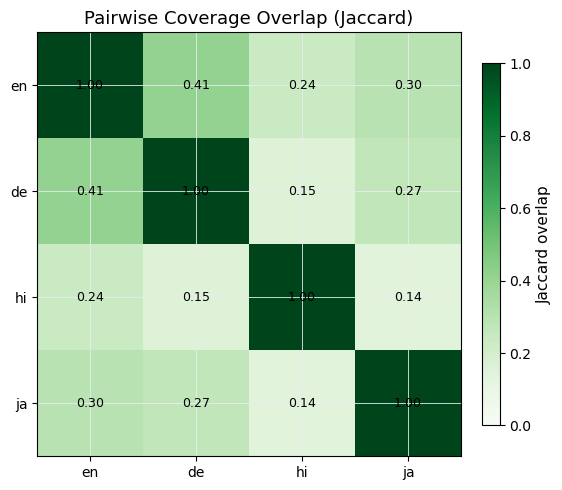

In [41]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Bar chart: coverage per language ---
coverage_pct = (presence.mean() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(coverage_pct.index, coverage_pct.values)
ax.set_ylim(0, 100)
ax.set_ylabel("Coverage (%)")
ax.set_title("Coverage by Language")
for i, v in enumerate(coverage_pct.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "coverage_bar_languages.png"), dpi=200)
plt.show()

# --- Pairwise Jaccard overlaps across languages ---
langs = list(presence.columns)
jac = pd.DataFrame(index=langs, columns=langs, dtype=float)

for a, b in itertools.product(langs, langs):
    A = set(presence.index[presence[a] == 1])
    B = set(presence.index[presence[b] == 1])
    inter = len(A & B)
    union = len(A | B) if len(A | B) else 1
    jac.loc[a, b] = inter / union

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(jac.values, cmap="Greens", vmin=0, vmax=1)
ax.set_xticks(np.arange(len(langs))); ax.set_yticks(np.arange(len(langs)))
ax.set_xticklabels(langs); ax.set_yticklabels(langs)
ax.set_title("Pairwise Coverage Overlap (Jaccard)")

# annotate cells (subtle)
for i in range(len(langs)):
    for j in range(len(langs)):
        ax.text(j, i, f"{jac.values[i, j]:.2f}", ha="center", va="center", fontsize=9)

cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("Jaccard overlap", rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "coverage_overlap_jaccard.png"), dpi=200)
plt.show()


Saved: ../plots/structural/graph_density_by_language.csv


,language,nodes,edges,density,source
1,de,142154,188768,0.000009,de_filtered_graph_expanded.pkl
0,en,408260,588918,0.000004,en_filtered_graph_expanded.pkl
2,hi,25090,54315,0.000086,hi_filtered_graph_expanded.pkl
3,ja,142814,233947,0.000011,ja_filtered_graph_expanded.pkl


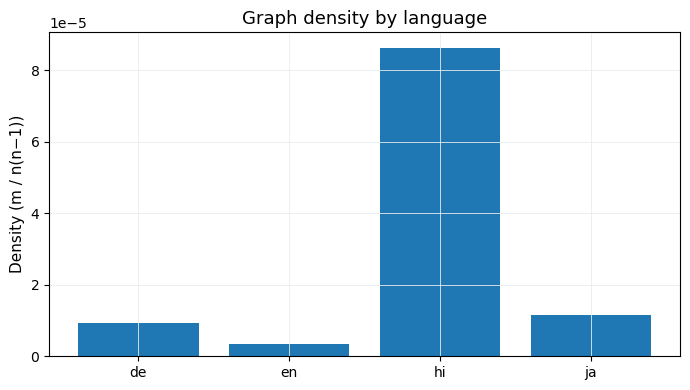

In [42]:
# %% [markdown]
# STRUCTURAL BIAS — Density per language
import os, pickle, networkx as nx, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = "../data"
PLOTS_DIR = "../plots/structural"
Path(PLOTS_DIR).mkdir(parents=True, exist_ok=True)

LANGS = ["en","de","hi","ja"]  # adjust if needed

def load_graph(lang):
    """Prefer expanded graph if available, else filtered; returns a DiGraph."""
    candidates = [f"{lang}_filtered_graph_expanded.pkl", f"{lang}_filtered_graph.pkl"]
    for fname in candidates:
        fp = os.path.join(DATA_DIR, fname)
        if os.path.exists(fp):
            with open(fp, "rb") as f:
                link_dict = pickle.load(f)
            G = nx.DiGraph()
            # build
            for src, tgts in link_dict.items():
                if not G.has_node(src): G.add_node(src)
                for tgt in tgts:
                    if not G.has_node(tgt): G.add_node(tgt)
                    G.add_edge(src, tgt)
            return G, fname
    return None, None

rows = []
for lang in LANGS:
    G, source = load_graph(lang)
    if G is None:
        print(f" {lang}: no graph found.")
        continue
    n, m = G.number_of_nodes(), G.number_of_edges()
    density = nx.density(G)  # for DiGraph: m / (n*(n-1))
    rows.append({"language": lang, "nodes": n, "edges": m, "density": density, "source": source})

dens_df = pd.DataFrame(rows).sort_values("language")
out_csv = os.path.join(PLOTS_DIR, "graph_density_by_language.csv")
dens_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)
display(dens_df)

# plot
plt.figure(figsize=(7,4))
plt.bar(dens_df["language"], dens_df["density"])
plt.ylabel("Density (m / n(n−1))")
plt.title("Graph density by language")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "density_bar.png"), dpi=200)
plt.show()


Loaded bias_metrics_perlang.csv: (3450, 8)


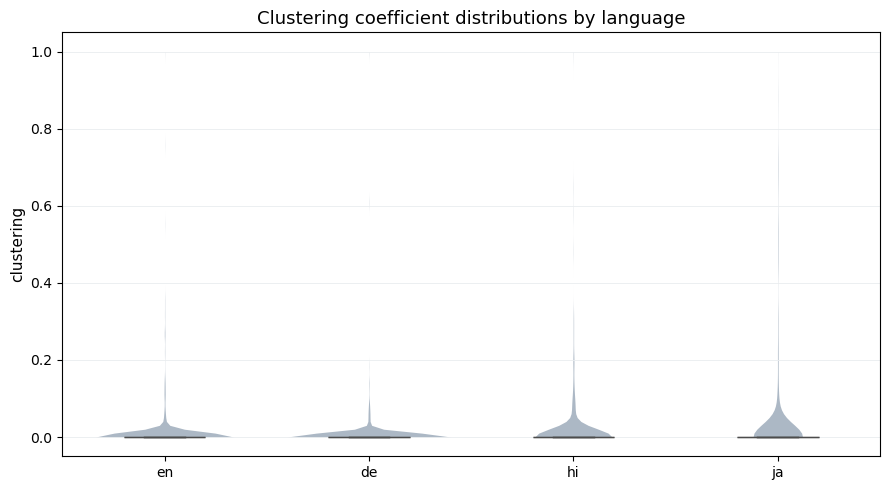

Saved: ../plots/structural/clustering_summary.csv


,language,count,mean,median,std
0,de,900,0.004223,0.0,0.041296
1,en,1291,0.008633,0.0,0.051017
2,hi,528,0.016729,0.0,0.073435
3,ja,731,0.031846,0.0,0.121996


In [43]:
# %% [markdown]
# STRUCTURAL BIAS — Clustering coefficient distributions
import os, pickle, networkx as nx, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = "../data"
PLOTS_DIR = "../plots/structural"
Path(PLOTS_DIR).mkdir(parents=True, exist_ok=True)

perlang_path = os.path.join(DATA_DIR, "bias_metrics_perlang.csv")
df = pd.read_csv(perlang_path)
print("Loaded bias_metrics_perlang.csv:", df.shape)

have_norm = "clustering_norm_perlang" in df.columns

if have_norm:
    plot_df = df[["language","clustering_norm_perlang"]].dropna().rename(columns={"clustering_norm_perlang":"clustering"})
else:
    # fallback: compute clustering from graphs and attach by node (title not present here),
    # so we’ll compute language-level distributions by sampling nodes from each graph.
    print(" No clustering_norm_perlang found; computing raw clustering from graphs.")
    LANGS = sorted(df["language"].unique())
    rows = []
    for lang in LANGS:
        # load graph
        for fname in [f"{lang}_filtered_graph_expanded.pkl", f"{lang}_filtered_graph.pkl"]:
            fp = os.path.join(DATA_DIR, fname)
            if os.path.exists(fp):
                with open(fp, "rb") as f:
                    link_dict = pickle.load(f)
                G = nx.DiGraph()
                for s, tgts in link_dict.items():
                    for t in tgts:
                        G.add_edge(s, t)
                clu = nx.clustering(G.to_undirected())
                for v, c in clu.items():
                    rows.append({"language": lang, "clustering": c})
                break
    plot_df = pd.DataFrame(rows)

# violin+box (subtle colors)
plt.figure(figsize=(9,5))
sns.violinplot(data=plot_df, x="language", y="clustering", inner=None, cut=0, linewidth=0, color="#a8b8c9")
sns.boxplot(data=plot_df, x="language", y="clustering", whis=1.5, width=0.4,
            boxprops=dict(alpha=0.6), showfliers=False, color="#6f7f8f")
plt.title("Clustering coefficient distributions by language")
plt.xlabel("")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "clustering_distributions.png"), dpi=200)
plt.show()

# also save per-language summary stats
summary = plot_df.groupby("language")["clustering"].agg(["count","mean","median","std"]).reset_index()
summary_csv = os.path.join(PLOTS_DIR, "clustering_summary.csv")
summary.to_csv(summary_csv, index=False)
print("Saved:", summary_csv)
display(summary)


Saved: ../plots/structural/components_summary.csv


,language,n_nodes,n_edges,n_components,largest_component,median_component
1,de,142154,188768,53,141745,7
0,en,408260,588918,38,407962,7
2,hi,25086,54315,37,24278,6
3,ja,142814,233947,6,142787,6


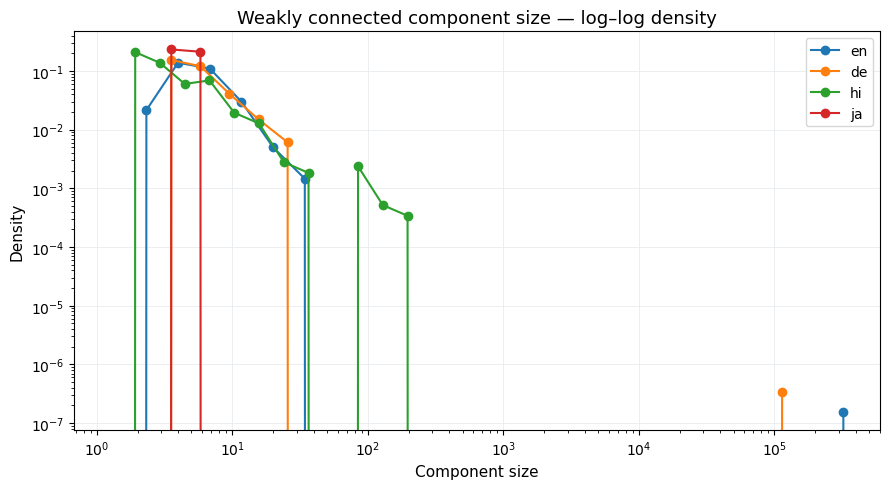

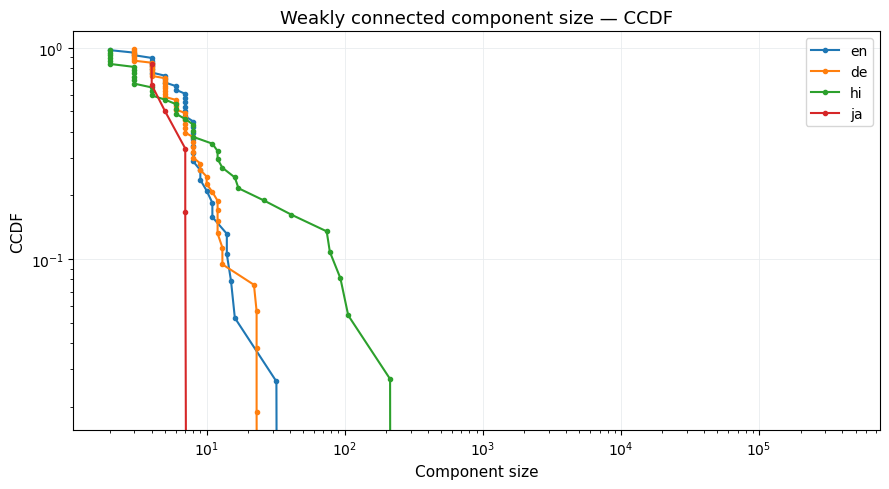

In [44]:
# %% [markdown]
# STRUCTURAL BIAS — Component size distributions (weakly connected)
import os, pickle, networkx as nx, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = "../data"
PLOTS_DIR = "../plots/structural"
Path(PLOTS_DIR).mkdir(parents=True, exist_ok=True)

LANGS = ["en","de","hi","ja"]  # adjust if needed

def load_graph(lang):
    for fname in [f"{lang}_filtered_graph_expanded.pkl", f"{lang}_filtered_graph.pkl"]:
        fp = os.path.join(DATA_DIR, fname)
        if os.path.exists(fp):
            with open(fp, "rb") as f:
                link_dict = pickle.load(f)
            G = nx.DiGraph()
            for s, tgts in link_dict.items():
                for t in tgts:
                    G.add_edge(s, t)
            return G, fname
    return None, None

comp_rows = []
sizes_by_lang = {}

for lang in LANGS:
    G, src = load_graph(lang)
    if G is None:
        print(f"{lang}: graph not found.")
        continue
    # weakly connected components
    wcc_sizes = [len(c) for c in nx.weakly_connected_components(G)]
    wcc_sizes.sort(reverse=True)
    sizes_by_lang[lang] = np.array(wcc_sizes, dtype=int)
    comp_rows.append({
        "language": lang,
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "n_components": len(wcc_sizes),
        "largest_component": wcc_sizes[0] if wcc_sizes else 0,
        "median_component": int(np.median(wcc_sizes)) if wcc_sizes else 0
    })

comp_summary = pd.DataFrame(comp_rows).sort_values("language")
comp_summary_csv = os.path.join(PLOTS_DIR, "components_summary.csv")
comp_summary.to_csv(comp_summary_csv, index=False)
print("Saved:", comp_summary_csv)
display(comp_summary)

# Plot size histogram (log bins) per language
plt.figure(figsize=(9,5))
for lang, sizes in sizes_by_lang.items():
    if len(sizes)==0: 
        continue
    bins = np.logspace(0, np.log10(max(sizes)), 25)
    hist, edges = np.histogram(sizes, bins=bins, density=True)
    centers = (edges[1:]+edges[:-1])/2
    plt.plot(centers, hist, marker='o', linestyle='-', label=lang)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Component size")
plt.ylabel("Density")
plt.title("Weakly connected component size — log–log density")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "components_size_loglog.png"), dpi=200)
plt.show()

# CCDF plot (clearer for heavy tails)
plt.figure(figsize=(9,5))
for lang, sizes in sizes_by_lang.items():
    if len(sizes)==0:
        continue
    s_sorted = np.sort(sizes)
    ccdf = 1.0 - np.arange(1, len(s_sorted)+1)/len(s_sorted)
    plt.plot(s_sorted, ccdf, marker='.', linestyle='-', label=lang)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Component size")
plt.ylabel("CCDF")
plt.title("Weakly connected component size — CCDF")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "components_size_ccdf.png"), dpi=200)
plt.show()
